In [1]:
import pandas as pd
import matplotlib.pyplot as plt
train = pd.read_csv("train.csv")

In [2]:
print(train.shape)
print(train.head())
print(train.info())
print(train.isna().sum())
train.describe()


(3000888, 6)
   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0
<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB
None
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [3]:
print(train["date"].min())
print(train["date"].max())
print(train["family"].nunique())
print(train["store_nbr"].value_counts().sort_index())

2013-01-01
2017-08-15
33
store_nbr
1     55572
2     55572
3     55572
4     55572
5     55572
6     55572
7     55572
8     55572
9     55572
10    55572
11    55572
12    55572
13    55572
14    55572
15    55572
16    55572
17    55572
18    55572
19    55572
20    55572
21    55572
22    55572
23    55572
24    55572
25    55572
26    55572
27    55572
28    55572
29    55572
30    55572
31    55572
32    55572
33    55572
34    55572
35    55572
36    55572
37    55572
38    55572
39    55572
40    55572
41    55572
42    55572
43    55572
44    55572
45    55572
46    55572
47    55572
48    55572
49    55572
50    55572
51    55572
52    55572
53    55572
54    55572
Name: count, dtype: int64


In [4]:
train["date"] = pd.to_datetime(train["date"])
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 137.4 MB


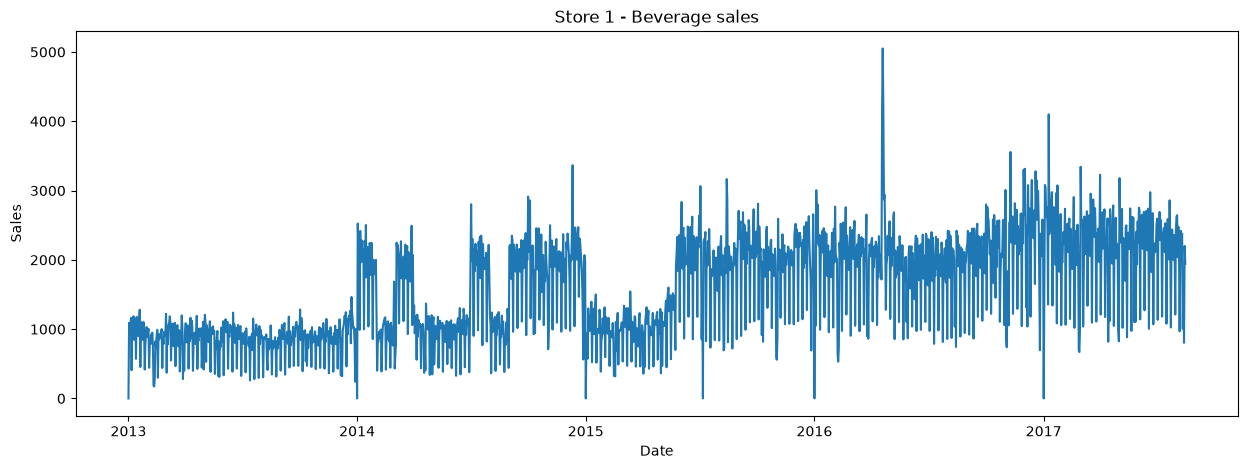

In [5]:
store1_beverages = train[
    (train["store_nbr"] == 1) &
    (train["family"] == 'BEVERAGES')
]

store1_beverages.shape

plt.figure(figsize=(15, 5))
plt.plot(store1_beverages["date"], store1_beverages["sales"])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Store 1 - Beverage sales")
plt.show()


In [6]:
store1_beverages.loc[store1_beverages["sales"].idxmax()]
store1_beverages["day_of_week"] = store1_beverages["date"].dt.dayofweek
store1_beverages.groupby("day_of_week")["sales"].mean()

day_of_week
0    1700.294606
1    1651.483471
2    1847.425000
3    1576.458333
4    1732.033333
5    1820.576763
6     784.000000
Name: sales, dtype: float64

In [7]:
print(train["date"].dtype)
print(store1_beverages["date"].dtype)

datetime64[us]
datetime64[us]


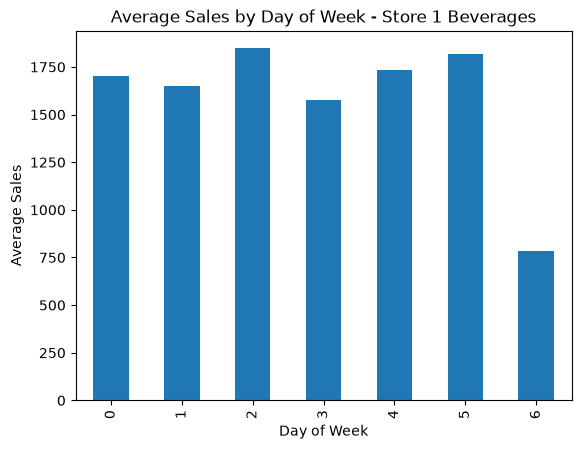

In [8]:
weekday_sales = store1_beverages.groupby("day_of_week")["sales"].mean()

weekday_sales.plot(kind="bar")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.title("Average Sales by Day of Week - Store 1 Beverages")
plt.show()

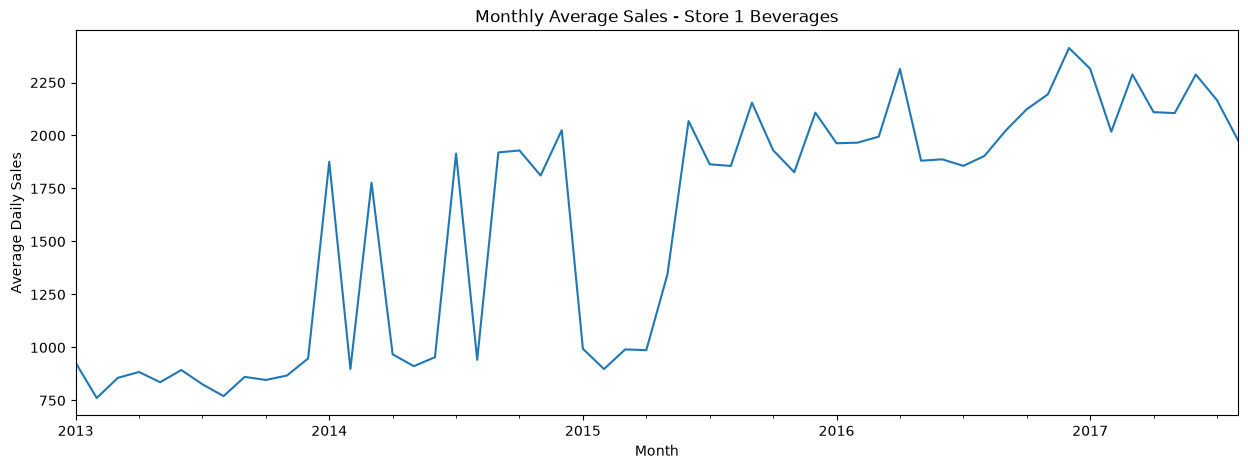

In [9]:
monthly_sales = (
    store1_beverages
    .groupby(store1_beverages["date"].dt.to_period("M"))["sales"]
    .mean()
)
monthly_sales.plot(figsize=(15, 5))
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")
plt.title("Monthly Average Sales - Store 1 Beverages")
plt.show()

In [10]:
monthly_pattern = (
    store1_beverages
    .groupby(store1_beverages["date"].dt.month)["sales"]
    .mean()
)

print(monthly_pattern)

date
1     1615.354839
2     1313.063830
3     1581.470968
4     1452.573333
5     1415.741935
6     1618.120000
7     1725.677419
8     1433.661871
9     1739.716667
10    1707.596774
11    1675.000000
12    1873.400000
Name: sales, dtype: float64


In [11]:
year_month_sales = (
    store1_beverages
    .groupby(store1_beverages["date"].dt.to_period("M"))["sales"]
    .mean()
)

print(year_month_sales)

date
2013-01     928.290323
2013-02     761.500000
2013-03     856.774194
2013-04     884.233333
2013-05     835.903226
2013-06     893.533333
2013-07     826.161290
2013-08     770.419355
2013-09     861.233333
2013-10     846.548387
2013-11     867.600000
2013-12     948.033333
2014-01    1876.193548
2014-02     898.178571
2014-03    1777.032258
2014-04     967.533333
2014-05     911.709677
2014-06     953.766667
2014-07    1914.612903
2014-08     941.451613
2014-09    1920.133333
2014-10    1929.419355
2014-11    1811.233333
2014-12    2024.966667
2015-01     993.967742
2015-02     898.107143
2015-03     990.774194
2015-04     987.166667
2015-05    1344.387097
2015-06    2068.166667
2015-07    1864.161290
2015-08    1856.419355
2015-09    2154.700000
2015-10    1930.548387
2015-11    1827.000000
2015-12    2107.766667
2016-01    1963.419355
2016-02    1966.206897
2016-03    1994.806452
2016-04    2313.733333
2016-05    1881.000000
2016-06    1887.566667
2016-07    1856.709677
2016-0

In [12]:
train.groupby("onpromotion")["sales"].mean().head(20)
promo_sales = train.groupby(
    train["onpromotion"] > 0
)["sales"].mean()

print(promo_sales)

onpromotion
False     158.246681
True     1137.693730
Name: sales, dtype: float64


In [13]:
train["date"].max()

Timestamp('2017-08-15 00:00:00')

In [14]:
validation_start = train["date"].max() - pd.Timedelta(days=14)

In [15]:
train_data = train[train["date"] < validation_start]
validation_data = train[train["date"] >= validation_start]

In [16]:
print(train_data["date"].min(), train_data["date"].max())
print(validation_data["date"].min(), validation_data["date"].max())
print(validation_data.shape)

2013-01-01 00:00:00 2017-07-31 00:00:00
2017-08-01 00:00:00 2017-08-15 00:00:00
(26730, 6)


In [17]:
validation_data["lag_date"] = validation_data["date"] - pd.Timedelta(days=7)